<a href="https://colab.research.google.com/github/ahmed-zunaira/APS360_Project/blob/main/notebooks/APS360_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APS360 Project: Anomaly Detection of Phytoplankton


## 1. Install

#### Install Python packages

In [1]:
!git clone https://github.com/ahmed-zunaira/APS360_Project.git

Cloning into 'APS360_Project'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 69 (delta 31), reused 38 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 40.56 MiB | 38.63 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [2]:
%cd APS360_Project

/content/APS360_Project


In [3]:
!pip install earthaccess xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 101.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is 

## 2. Analysis


In [4]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [5]:
!python src/train.py

Epoch 1: Train Loss: 0.03986778319813311, Validation Loss: 0.020166537258774042
Epoch 2: Train Loss: 0.01860613872607549, Validation Loss: 0.013967709460606178
Epoch 3: Train Loss: 0.011575768953965357, Validation Loss: 0.00953774293884635
Epoch 4: Train Loss: 0.009536817107194414, Validation Loss: 0.008222064701840281
Epoch 5: Train Loss: 0.008679426702049872, Validation Loss: 0.007605608319863677
Epoch 6: Train Loss: 0.008121607223680863, Validation Loss: 0.0072289675784607725
Epoch 7: Train Loss: 0.007716524899781992, Validation Loss: 0.007058403066669901
Epoch 8: Train Loss: 0.007517648220527917, Validation Loss: 0.007214056871210535
Epoch 9: Train Loss: 0.007482658664230257, Validation Loss: 0.0067193175200372934
Epoch 10: Train Loss: 0.0072248917519270135, Validation Loss: 0.00648527864056329
Epoch 11: Train Loss: 0.006945749337319285, Validation Loss: 0.00642584846355021
Epoch 12: Train Loss: 0.006820847959412883, Validation Loss: 0.006688894471153617
Epoch 13: Train Loss: 0.006

In [5]:
%cd /content/APS360_Project/src

/content/APS360_Project/src


In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import os

from autoencoder import Autoencoder
from data_loader import Dataload

In [7]:
def setup_inference (model_path, dataloader):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    data_iter = iter(dataloader) # get first batch of images

    imgs, _ = next(data_iter)

    return model, imgs # return model and one batch of images

def calculate_difference_map (model, images):
    with torch.no_grad():
        recons = model(images) # get model's reconstructions

        diff_map = torch.abs(images - recons) # calculate differene between reconstructions and images

        return recons, diff_map

def plot_triplets(images, reconstructions, difference_maps, num_to_plot=3):
    fig, axes = plt.subplots(nrows=num_to_plot, ncols=3, figsize=(12, 4 * num_to_plot))

    for i in range(num_to_plot):
        image = images[i]
        recon = reconstructions[i]
        diff_map = difference_maps[i]

        image_np = image.detach().numpy()
        recon_np = recon.detach().numpy()
        diff_map_np = diff_map.detach().numpy()

        # remove channel dimension
        image_np = image_np.squeeze(0)
        recon_np = recon_np.squeeze(0)
        diff_map_np = diff_map_np.squeeze(0)

        axes[i, 0].imshow(image_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 0].axis('off')
        axes[i, 0].set_title("Original")

        axes[i, 1].imshow(recon_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 1].axis('off')
        axes[i, 1].set_title("Reconstruction")

        axes[i, 2].imshow(diff_map_np, cmap='hot', vmin=0.0, vmax=1.0)
        axes[i, 2].axis('off')
        axes[i, 2].set_title("Difference")
    plt.tight_layout()
    plt.show()

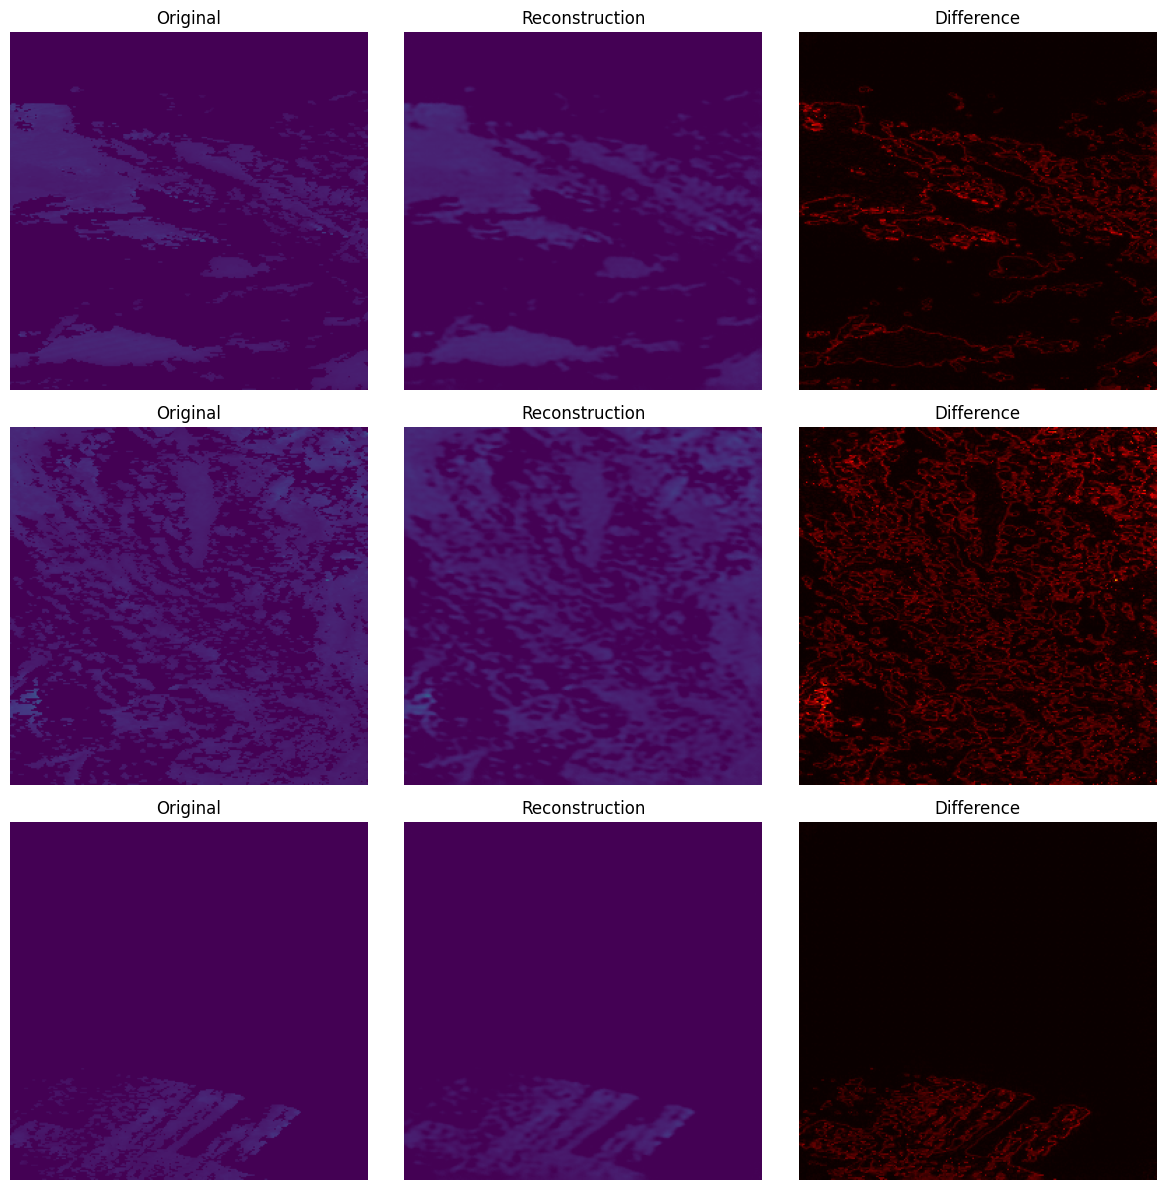

In [10]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
model_weights_file = "/content/APS360_Project/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

In [8]:
def setup_eval_environment(model_path, processed_dir):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    dataset = Dataload(processed_dir)

    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    return model, dataloader

def calculate_all_losses(model, dataloader, pixel_threshold=0.5):
    criterion = nn.MSELoss()

    model.eval()

    all_losses = []

    # get MSE loss for each image and reconstruction from model
    with torch.no_grad():
        for data in dataloader:
            imgs, _ = data
            recons = model(imgs)

            #mask = (imgs > 0.0).float()
            #sq_diff = (recons - imgs) ** 2
            #masked_sq_diff = sq_diff * mask

            #anomalous_pixels = (masked_sq_diff > pixel_threshold).float()
            #valid_pixels = mask.sum() + 1e-8
            #anomaly_percentage = (anomalous_pixels.sum() / valid_pixels) * 100
            #all_losses.append(anomaly_percentage.item())
            loss = criterion (imgs, recons)
            all_losses.append(loss.item())

    return all_losses

def find_threshold(losses_list, percentile=95):
    losses_np = np.array(losses_list)

    threshold = np.percentile(losses_np, 95)

    return threshold

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os

from autoencoder import Autoencoder
from data_loader import Dataload

In [13]:
model, dataloader = setup_eval_environment(model_weights_file, processed_dir)

losses = calculate_all_losses(model, dataloader)

threshold = find_threshold(losses)

print ("Calculated threshold:", threshold)
print (np.array(losses))

Calculated threshold: 0.00812941780313849
[1.40604749e-03 4.40900121e-03 5.97249484e-04 2.70284712e-03
 3.05136223e-03 4.07230761e-03 2.02981848e-03 1.88995409e-03
 2.65188888e-03 2.12919479e-03 6.48582540e-03 5.22119086e-03
 4.38433420e-03 3.07349896e-04 8.77102558e-03 6.17897371e-03
 2.59338203e-03 3.27681587e-03 3.91541328e-03 1.75829814e-03
 6.67553559e-06 3.68819665e-03 6.67553559e-06 6.11435156e-03
 2.43941392e-03 8.91652249e-04 3.16581526e-03 1.34550629e-03
 6.60764053e-05 6.67553559e-06 3.15047102e-03 1.71017200e-05
 5.50794229e-03 5.95221296e-03 2.77641229e-05 5.34194149e-03
 3.12081329e-03 5.76680759e-03 2.69831531e-03 1.99074973e-03
 1.43943780e-05 6.67553559e-06 7.26324855e-04 8.89616832e-03
 3.18433950e-03 5.10359742e-03 4.87788673e-03 2.81325076e-03
 2.99336785e-03 6.63121638e-04 2.92126718e-03 1.44457933e-03
 1.18120888e-03 2.01119296e-03 3.45268357e-03 1.07848282e-05
 3.95670719e-03 3.24171339e-03 4.96017467e-03 2.75411224e-03
 5.56049775e-03 3.09772277e-03 6.67553559e-

In [13]:
processed_blob_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_blob_data"

model, dataloader = setup_eval_environment(model_weights_file, processed_blob_dir)

blob_losses = calculate_all_losses(model, dataloader)

print (np.array(blob_losses))

[2.24235170e-02 2.40052566e-02 1.76664740e-02 2.11449135e-02
 3.03660315e-02 2.64181532e-02 2.60512214e-02 3.81992683e-02
 8.39565706e-04 1.48066581e-04 1.78893022e-02 7.25080259e-03
 3.18271779e-02 3.09061948e-02 3.56355533e-02 3.03817783e-02
 2.60063037e-02 2.21732501e-02 2.62048263e-02 1.66467186e-02
 5.42289997e-03 1.67516731e-02 2.50873938e-02 1.30933030e-02
 8.91106203e-03 2.83967275e-02 1.91263061e-05 2.43631774e-03
 2.12126840e-02 1.79324001e-02 1.75699443e-02 1.98258981e-02
 2.41949819e-02 2.73166969e-02 2.63552205e-03 3.18331942e-02
 1.53738614e-02 4.19164263e-03 2.95789763e-02 2.17838343e-02
 3.47301401e-02 1.69347581e-02 6.60080742e-03 2.21576802e-02
 3.76693271e-02 3.71130859e-03 8.66786856e-03 2.51798145e-02
 2.66162399e-02 3.24381106e-02 1.01486016e-02 1.78763829e-02
 2.64524259e-02 2.43945569e-02 8.71982053e-03 2.37151515e-02
 9.36290249e-03 1.56243434e-02 1.25629744e-02 2.67424490e-02
 1.32399593e-02 2.35960186e-02 1.63431391e-02 1.75640937e-02
 2.31831043e-04 2.527174

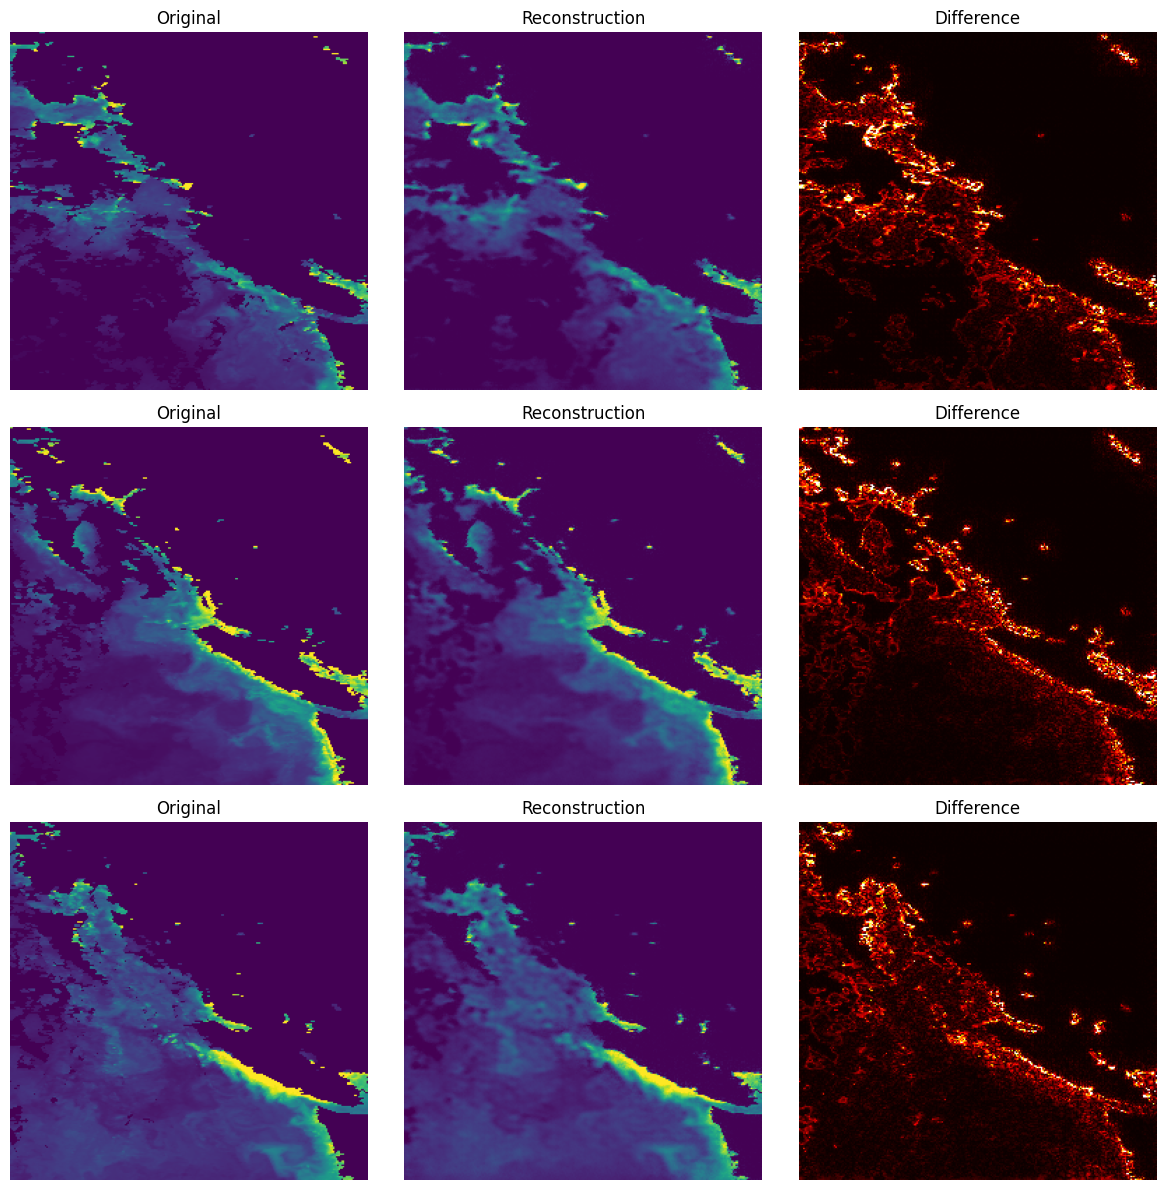

In [14]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_blob_data"
model_weights_file = "/content/APS360_Project/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

In [10]:
def moving_average(data, window_size=4):
  return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

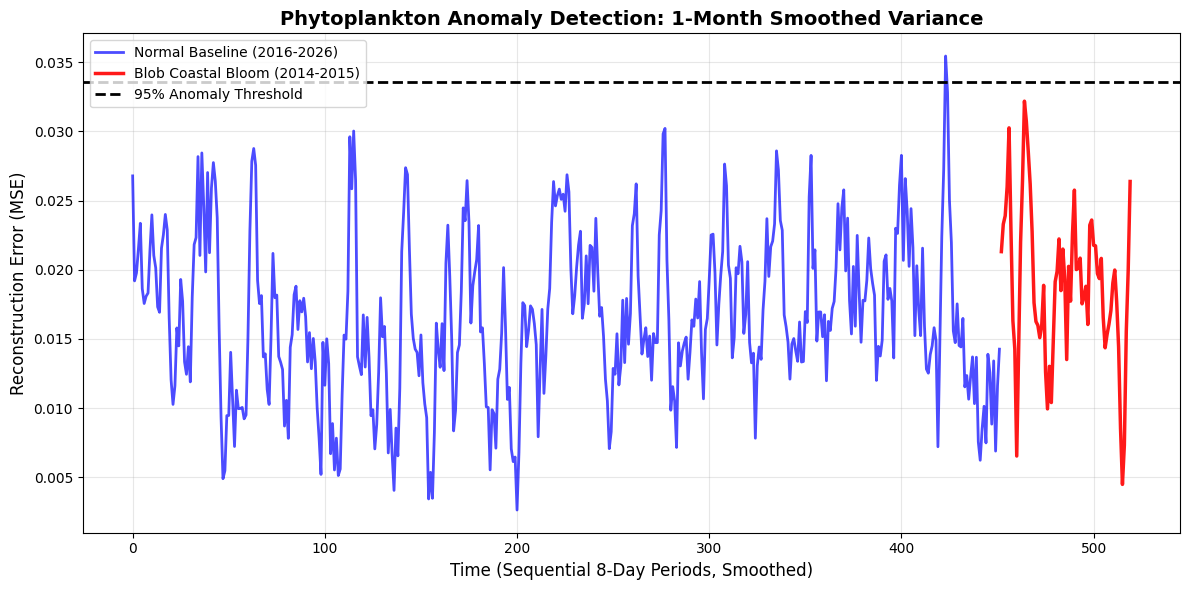

In [18]:
normal_losses_smoothed = moving_average(np.array(losses))
blob_losses_smoothed = moving_average(np.array(blob_losses))

plt.figure(figsize=(12, 6))

x_normal = range(len(normal_losses_smoothed))
x_blob = range(len(normal_losses_smoothed), len(normal_losses_smoothed) + len(blob_losses_smoothed))

plt.plot(x_normal, normal_losses_smoothed, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2026)')
plt.plot(x_blob, blob_losses_smoothed, color='red', alpha=0.9, linewidth=2.5, label='Blob Coastal Bloom (2014-2015)')
plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'95% Anomaly Threshold')

plt.title("Phytoplankton Anomaly Detection: 1-Month Smoothed Variance", fontsize=14, fontweight='bold')
plt.xlabel("Time (Sequential 8-Day Periods, Smoothed)", fontsize=12)
plt.ylabel("Reconstruction Error (MSE)", fontsize=12)

plt.fill_between(x_blob, blob_losses_smoothed, threshold, where=(blob_losses_smoothed > threshold), color='red', alpha=0.2, interpolate=True)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("final_smoothed_results.png", dpi=300)
plt.show()

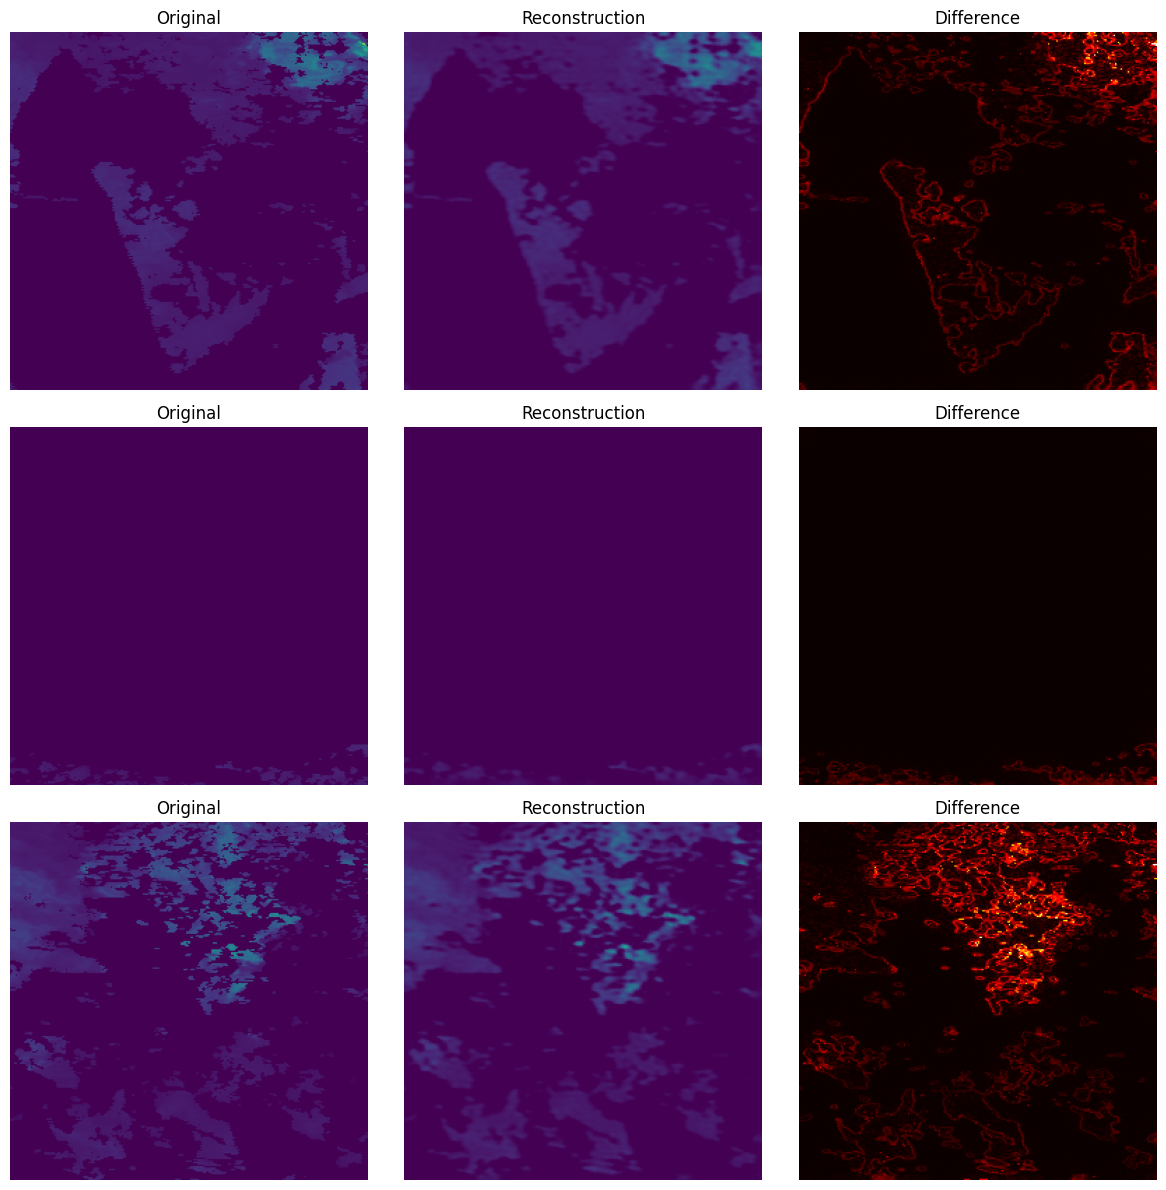

In [14]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"
model_weights_file = "/content/APS360_Project/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

In [14]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
model_weights_file = "/content/APS360_Project/CAE_model.pth"

model, dataloader = setup_eval_environment(model_weights_file, processed_dir)

losses = calculate_all_losses(model, dataloader)

threshold = find_threshold(losses)

print ("Calculated threshold:", threshold)

Calculated threshold: 0.00812941780313849


In [15]:
processed_anomaly_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"

model, dataloader = setup_eval_environment(model_weights_file, processed_anomaly_dir)

anomaly_losses = calculate_all_losses(model, dataloader)

In [16]:
normal_losses_smoothed = moving_average(np.array(losses))
anomaly_losses_smoothed = moving_average(np.array(anomaly_losses))

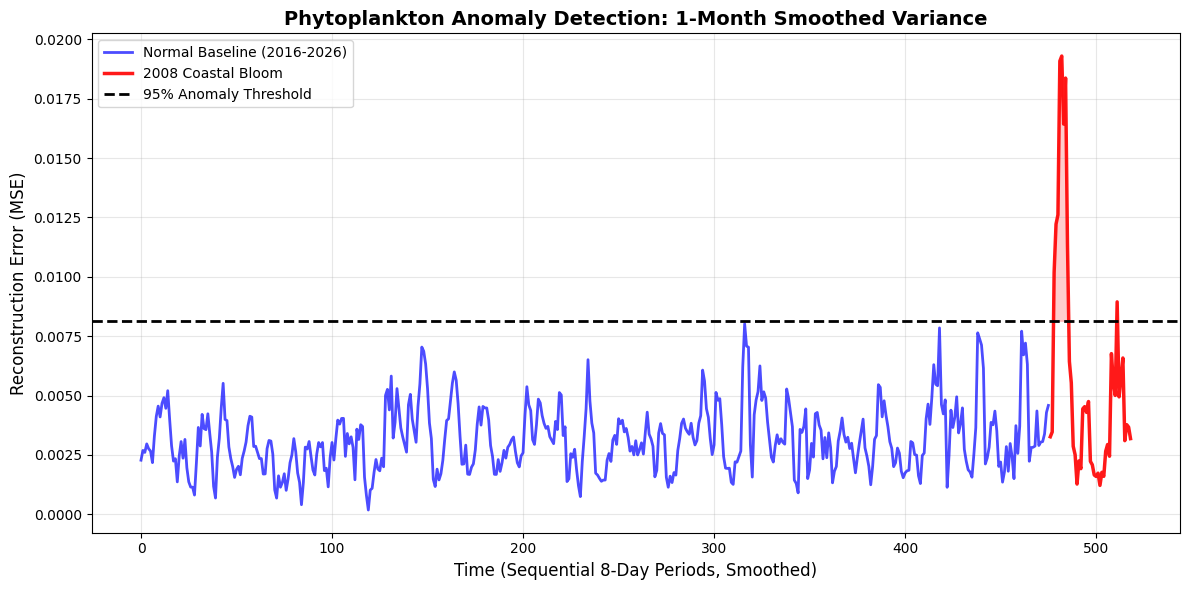

In [18]:
plt.figure(figsize=(12, 6))

x_normal = range(len(normal_losses_smoothed))
x_anomaly = range(len(normal_losses_smoothed), len(normal_losses_smoothed) + len(anomaly_losses_smoothed))

plt.plot(x_normal, normal_losses_smoothed, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2026)')
plt.plot(x_anomaly, anomaly_losses_smoothed, color='red', alpha=0.9, linewidth=2.5, label='2008 Coastal Bloom')
plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'95% Anomaly Threshold')

plt.title("Phytoplankton Anomaly Detection: 1-Month Smoothed Variance", fontsize=14, fontweight='bold')
plt.xlabel("Time (Sequential 8-Day Periods, Smoothed)", fontsize=12)
plt.ylabel("Reconstruction Error (MSE)", fontsize=12)

plt.fill_between(x_anomaly, anomaly_losses_smoothed, threshold, where=(anomaly_losses_smoothed > threshold), color='red', alpha=0.2, interpolate=True)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("final_smoothed_results.png", dpi=300)
plt.show()

In [16]:
print (np.array(losses))

print(np.array(anomaly_losses))

[4.94643115e-02 2.28401329e-02 1.65272057e-02 1.83128640e-02
 1.91017594e-02 2.51672864e-02 2.34232266e-02 2.57468093e-02
 1.97860412e-04 2.08724421e-02 2.55080201e-02 2.66955271e-02
 1.25344787e-02 3.11371014e-02 1.37687540e-02 2.31077485e-02
 1.24833605e-03 2.95678303e-02 3.23044695e-02 2.70252079e-02
 7.09920144e-03 2.50784233e-02 6.92464551e-03 9.03708860e-03
 1.89002367e-05 3.04489564e-02 2.36726832e-02 3.83591140e-03
 1.92355625e-02 2.41570920e-02 6.13849796e-03 2.32255203e-04
 2.72193961e-02 1.39765292e-02 3.06831785e-02 1.54090701e-02
 2.92293206e-02 3.74042727e-02 2.09561153e-03 4.50555384e-02
 1.37132555e-02 1.84998494e-02 3.08500677e-02 2.18534991e-02
 3.24663818e-02 2.58222818e-02 2.55085006e-02 1.12687647e-02
 4.15235409e-04 1.89002367e-05 7.86564779e-03 1.35878427e-02
 1.63514428e-02 3.50054033e-05 2.61504501e-02 3.56733108e-05
 2.66425521e-03 1.63152795e-02 2.08102614e-02 7.42124830e-05
 2.98858737e-03 1.30155319e-02 2.19205301e-02 2.26019435e-02
 3.36255692e-02 3.325488

In [17]:
# baseline model

import glob
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [18]:
def load_flattened_data(path):
  files = glob.glob(f"{path}/*.pt")
  data = []
  for curr_file in files:
    img = torch.load(curr_file, weights_only=False).numpy().flatten()
    data.append(img)
  return np.array(data)

In [19]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
processed_anomaly_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"

train_data = load_flattened_data(processed_dir)
test_data = load_flattened_data(processed_anomaly_dir)

pca = PCA(n_components=64)

pca.fit(train_data)

train_compressed = pca.transform(train_data)
train_reconstructed = pca.inverse_transform(train_compressed)

test_compressed = pca.transform(test_data)
test_reconstructed = pca.inverse_transform(test_compressed)

normal_loss = np.mean((train_data - train_reconstructed)**2, axis=1)
anomaly_loss = np.mean((test_data - test_reconstructed)**2, axis=1)
threshold = np.percentile(normal_loss, 95)

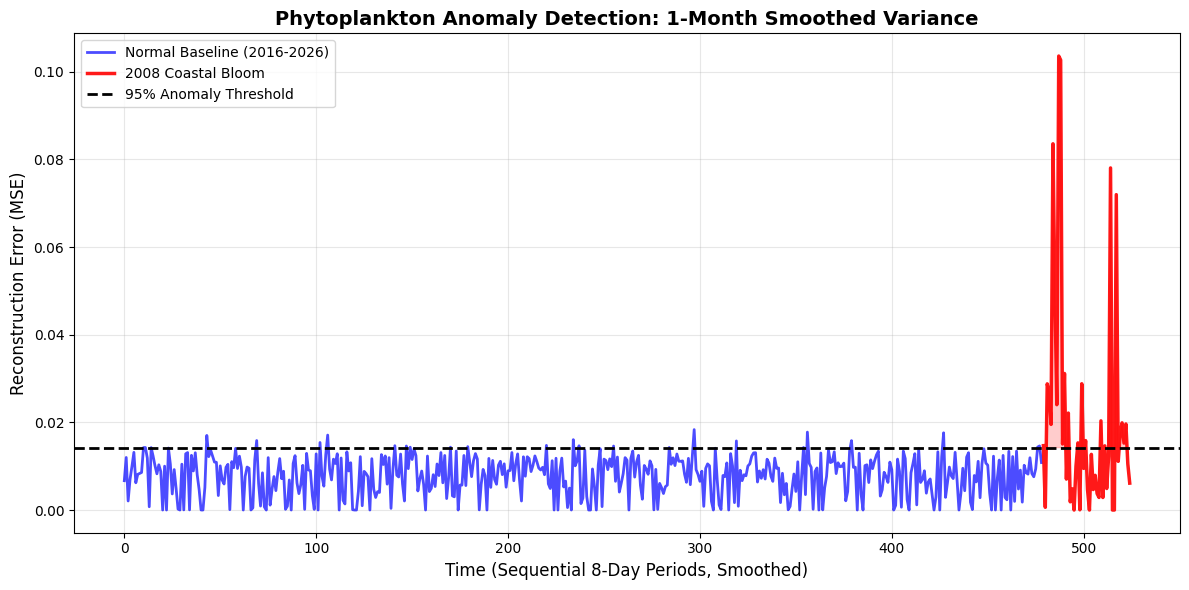

In [24]:
plt.figure(figsize=(12, 6))

x_normal = range(len(normal_loss))
x_anomaly = range(len(normal_loss), len(normal_loss) + len(anomaly_loss))

plt.plot(x_normal, normal_loss, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2026)')
plt.plot(x_anomaly, anomaly_loss, color='red', alpha=0.9, linewidth=2.5, label='2008 Coastal Bloom')
plt.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'95% Anomaly Threshold')

plt.title("Phytoplankton Anomaly Detection: 1-Month Smoothed Variance", fontsize=14, fontweight='bold')
plt.xlabel("Time (Sequential 8-Day Periods, Smoothed)", fontsize=12)
plt.ylabel("Reconstruction Error (MSE)", fontsize=12)

plt.fill_between(x_anomaly, anomaly_loss, threshold, where=(anomaly_loss > threshold), color='red', alpha=0.2, interpolate=True)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("final_smoothed_results.png", dpi=300)
plt.show()

In [20]:
def compute_z_scores (normal_data, anomaly_data):
  normal_baseline_mean = np.mean(normal_data)
  normal_baseline_std = np.std(normal_data)

  # preventing dividing by zero
  if normal_baseline_std == 0:
    normal_baseline_std = 1e-8

  z_normal = (normal_data - normal_baseline_mean) / normal_baseline_std
  z_anomaly = (anomaly_data - normal_baseline_mean) / normal_baseline_std

  return z_normal, z_anomaly

In [21]:
def plot_z_scores(ae_z_normal, ae_z_anomaly, pca_z_normal, pca_z_anomaly, ae_threshold, pca_threshold):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  min_val_ae_normal = np.min(ae_z_normal)
  min_val_ae_anomaly = np.min(ae_z_anomaly)
  min_val_pca_normal = np.min(pca_z_normal)
  min_val_pca_anomaly = np.min(pca_z_anomaly)
  min_val = min(min_val_ae_normal, min_val_ae_anomaly, min_val_pca_normal, min_val_pca_anomaly)

  max_val_ae_normal = np.max(ae_z_normal)
  max_val_ae_anomaly = np.max(ae_z_anomaly)
  max_val_pca_normal = np.max(pca_z_normal)
  max_val_pca_anomaly = np.max(pca_z_anomaly)
  max_val = max(max_val_ae_normal, max_val_ae_anomaly, max_val_pca_normal, max_val_pca_anomaly)

  ax1.set_ylim(min_val - 0.5, max_val + 0.5) # adding buffers so it doesnt hit top/bottom
  ax2.set_ylim(min_val - 0.5, max_val + 0.5)

  x_ae_normal = range(len(ae_z_normal))
  x_ae_anomaly = range(len(ae_z_normal), len(ae_z_normal) + len(ae_z_anomaly))

  x_pca_normal = range(len(pca_z_normal))
  x_pca_anomaly = range(len(pca_z_normal), len(pca_z_normal) + len(pca_z_anomaly))

  ax1.plot(x_ae_normal, ae_z_normal, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2026)')
  ax1.plot(x_ae_anomaly, ae_z_anomaly, color='red', alpha=0.7, linewidth=2, label='2008 Coastal Bloom')
  ax1.axhline(y=ae_threshold, color='black', linestyle='--', label='95% Threshold')
  ax1.fill_between(x_ae_anomaly, ae_z_anomaly, ae_threshold, where=(ae_z_anomaly > ae_threshold), color='red', alpha=0.2, interpolate=True)

  ax1.set_title("Convolutional Autoencoder")
  ax1.legend()

  ax2.plot(x_pca_normal, pca_z_normal, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2026)')
  ax2.plot(x_pca_anomaly, pca_z_anomaly, color='red', alpha=0.7, linewidth=2, label='2008 Coastal Bloom')
  ax2.axhline(y=pca_threshold, color='black', linestyle='--', label='95% Threshold')
  ax2.fill_between(x_pca_anomaly, pca_z_anomaly, pca_threshold, where=(pca_z_anomaly > pca_threshold), color='red', alpha=0.2, interpolate=True)

  ax2.set_title("PCA Baseline")
  ax2.legend()

  plt.tight_layout()
  plt.show()


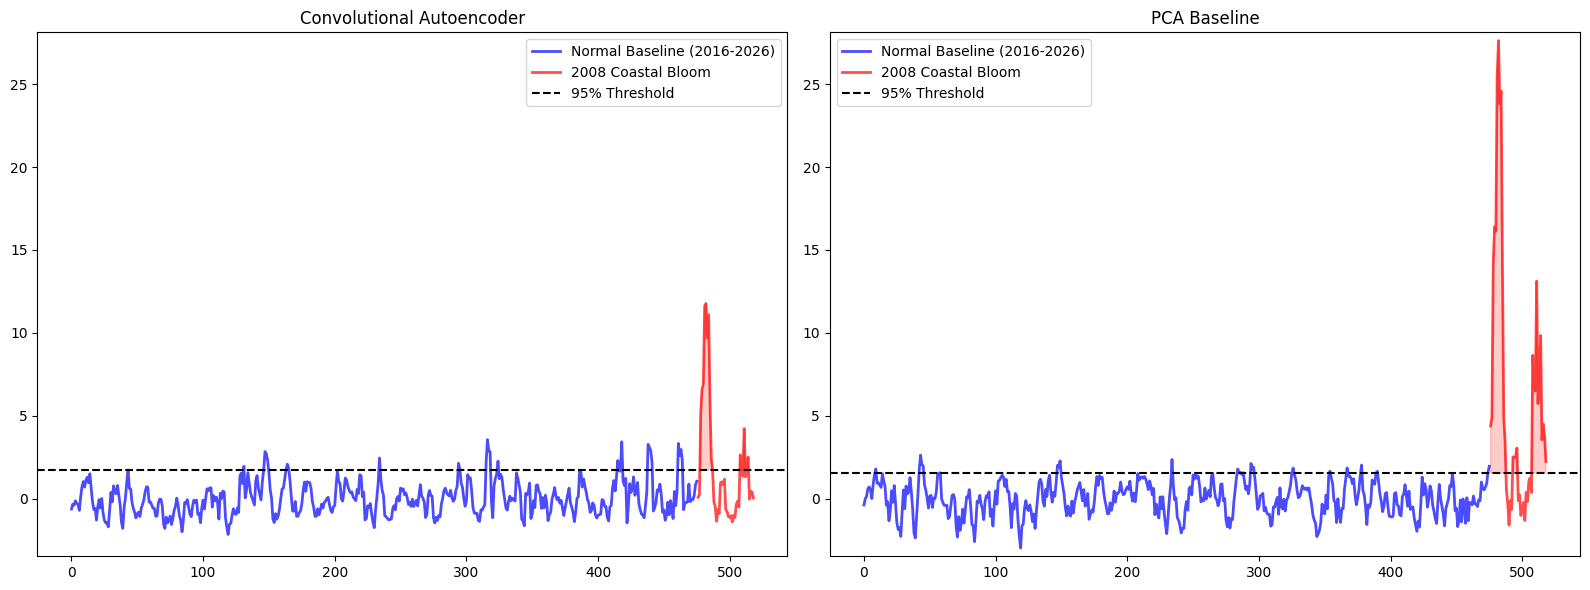

In [22]:
pca_normal_losses_smooth = moving_average(normal_loss)
pca_anomaly_losses_smooth = moving_average(anomaly_loss)

ae_z_normal, ae_z_anomaly = compute_z_scores(normal_losses_smoothed, anomaly_losses_smoothed)
pca_z_normal, pca_z_anomaly = compute_z_scores(pca_normal_losses_smooth, pca_anomaly_losses_smooth)

ae_threshold = np.percentile(ae_z_normal, 95)
pca_threshold = np.percentile(pca_z_normal, 95)

plot_z_scores(ae_z_normal, ae_z_anomaly, pca_z_normal, pca_z_anomaly, ae_threshold, pca_threshold)